In [15]:
!pip install tensorflowjs

In [16]:
import os
import zipfile
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
os.environ['KAGGLE_USERNAME'] = 'ahmadrifaat'
os.environ['KAGGLE_KEY'] = 'KGAT_4423c6a4e213ab5b50a964632bdbc262'

In [18]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
local_zip = 'intel-image-classification.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/intel_images')
zip_ref.close()

print("Dataset berhasil diunduh dan diekstrak!")

Dataset berhasil diunduh dan diekstrak!


In [20]:
def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path):
            continue
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images

        # sample resolusi
        for img_file in image_files[:10]:
            img_path = os.path.join(subdir_path, img_file)
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)
            except:
                pass

    print("\nBeberapa variasi resolusi gambar (Sampel):")
    for size in list(unique_sizes)[:5]:
        print(f"- {size}")
    print("---------------")
    print(f"Total Citra: {total_images}")

# cek folder
print_images_resolution('/content/intel_images/seg_train/seg_train')

forest: 2271
buildings: 2191
mountain: 2512
glacier: 2404
street: 2382
sea: 2274

Beberapa variasi resolusi gambar (Sampel):
- (150, 150)
- (150, 134)
---------------
Total Citra: 14034


In [21]:
TRAIN_DIR = '/content/intel_images/seg_train/seg_train'
TEST_DIR = '/content/intel_images/seg_test/seg_test'

In [22]:
#augmentasi data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

#generator data validation dan testing
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

#load data
BATCH_SIZE = 64
IMG_SIZE = (150, 150)

print("--- Memuat Training Set ---")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training', #80% untuk training
    shuffle=True
)

print("\n--- Memuat Validation Set ---")
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation', #20% untuk Validation
    shuffle=False
)

print("\n--- Memuat Testing Set ---")
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# kamus label kelas
class_labels = list(train_generator.class_indices.keys())
print("\nDaftar Kelas yang terdeteksi:", class_labels)

--- Memuat Training Set ---
Found 11230 images belonging to 6 classes.

--- Memuat Validation Set ---
Found 2804 images belonging to 6 classes.

--- Memuat Testing Set ---
Found 3000 images belonging to 6 classes.

Daftar Kelas yang terdeteksi: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# CUSTOM CALLBACK
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # nilai akurasi training dan validation
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')

        # stop jika mencapai target >= 95%
        if train_acc is not None and val_acc is not None:
            if train_acc >= 0.95 and val_acc >= 0.95:
                print(f"\n[INFO] Epoch {epoch+1}: Akurasi training ({train_acc*100:.2f}%) dan validation ({val_acc*100:.2f}%) telah mencapai target >= 95%!")
                print("[INFO] Proses training dihentikan secara otomatis untuk menghemat waktu.")
                self.model.stop_training = True

# callback
my_callback = CustomCallback()

# arsitektur cnn
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Block 4
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Flatten & Dense Layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),  # Mengurangi overfitting

    # Output Layer (6 kelas, menggunakan Softmax)
    Dense(6, activation='softmax')
])

#ringkasan arsitektur model
model.summary()

#kompilasi model
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#training model
print("\n--- Memulai Proses Training Model ---")
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[my_callback],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,818,502 (26.01 MB)

 Trainable params: 6,816,518 (26.00 MB)

 Non-trainable params: 1,984 (7.75 KB)


--- Memulai Proses Training Model ---
Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 101s 529ms/step - accuracy: 0.5900 - loss: 1.2505 - val_accuracy: 0.1619 - val_loss: 5.2781
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 89s 508ms/step - accuracy: 0.6849 - loss: 0.8831 - val_accuracy: 0.2753 - val_loss: 3.2614
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 497ms/step - accuracy: 0.7191 - loss: 0.7782 - val_accuracy: 0.5717 - val_loss: 1.2165
Epoch 4/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 89s 504ms/step - accuracy: 0.7458 - loss: 0.7020 - val_accuracy: 0.6872 - val_loss: 0.8835
Epoch 5/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 499ms/step - accuracy: 0.7682 - loss: 0.6490 - val_accuracy: 0.7800 - val_loss: 0.6127
Epoch 6/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 500ms/step - accuracy: 0.7773 - loss: 0.6173 - val_accuracy: 0.6041 - val_loss: 1.0295
Epoch 7/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 87s 495ms/step - accuracy: 0.7922 - loss: 0.5720 - val_accuracy: 0.7118 - val_loss: 0.9111
Epoch 8/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s

In [12]:
#evaluasi mode
print("--- Mengevaluasi Model pada Testing Set ---")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\nHasil Evaluasi Akhir:")
print(f"- Loss pada Testing Set   : {test_loss:.4f}")
print(f"- Akurasi pada Testing Set: {test_accuracy * 100:.2f}%")

#validasi
if test_accuracy >= 0.85:
    print("memenuhi kriteria minimal 85%.")
else:
    print("dibawah kriteria minimal 85%")

--- Mengevaluasi Model pada Testing Set ---
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8650 - loss: 0.3943

Hasil Evaluasi Akhir:
- Loss pada Testing Set   : 0.3943
- Akurasi pada Testing Set: 86.50%
memenuhi kriteria minimal 85%.


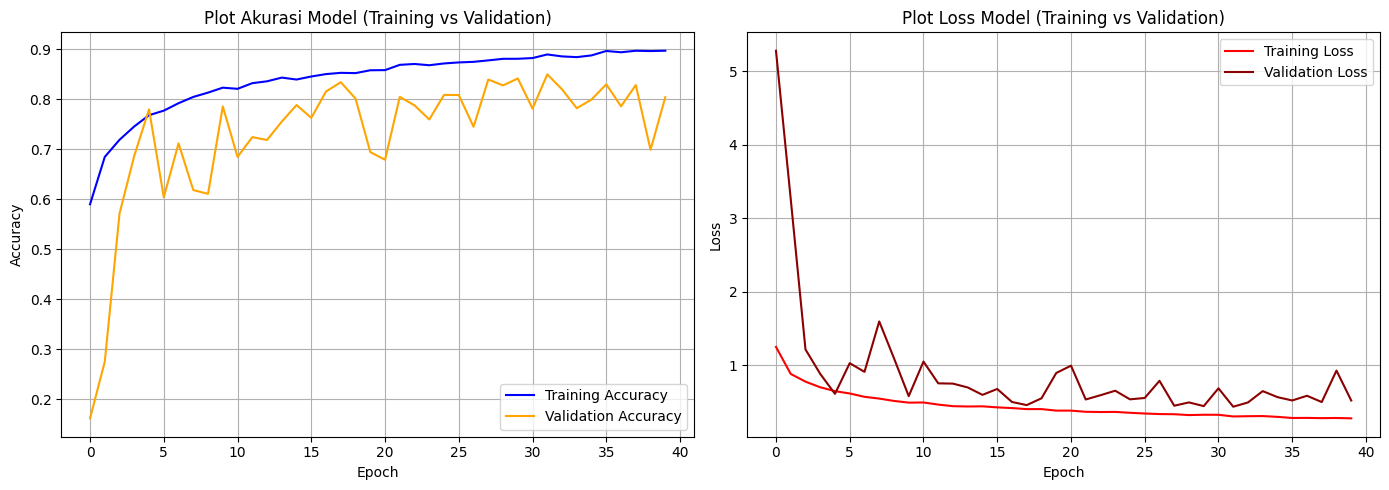

In [24]:
#plot akurasi dan loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

#akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('Plot Akurasi Model (Training vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

#loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='darkred')
plt.title('Plot Loss Model (Training vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
#saved model
os.makedirs('submission/saved_model', exist_ok=True)
model.export('submission/saved_model')
print("[OK] Model berhasil disimpan dalam format SavedModel!")


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133979749432784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133979749432592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133979749432208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133981174120912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133979749432976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133979749433168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133981174120720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133981174121296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133981174121680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133981174122832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13398

In [27]:
#TF-Lite
os.makedirs('submission/tflite', exist_ok=True)
converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
tflite_model = converter.convert()

#save file
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
print("[OK] Model berhasil dikonversi ke format TF-Lite!")

#label.txt
with open('submission/tflite/label.txt', 'w') as f:
    for label in class_labels:
        f.write(f"{label}\n")
print("[OK] Berkas label.txt berhasil dibuat untuk folder TF-Lite!")

[OK] Model berhasil dikonversi ke format TF-Lite!
[OK] Berkas label.txt berhasil dibuat untuk folder TF-Lite!


In [29]:
#TFJS
os.makedirs('submission/tfjs_model', exist_ok=True)

!tensorflowjs_converter --input_format=tf_saved_model submission/saved_model submission/tfjs_model

print("[OK] Model berhasil dikonversi ke format TFJS (model.json & shard weights)!")

2026-06-03 09:24:07.510649: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780478647.627535   47324 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780478647.661704   47324 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780478647.729492   47324 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780478647.731176   47324 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780478647.731205   47324 computation_placer.cc:177] computation placer alr

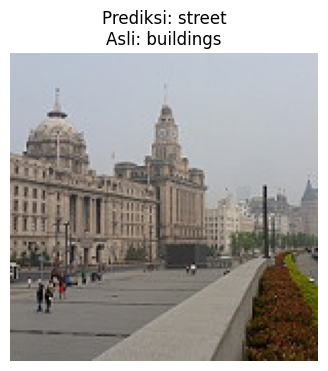

Hasil Probabilitas Distribusi: [3.1466874e-01 3.9486958e-06 3.0527126e-08 1.7091411e-07 7.8819500e-07
 6.8532640e-01]


In [31]:
#inference
import numpy as np

#load model TF-Lite
interpreter = tf.lite.Interpreter(model_path="submission/tflite/model.tflite")
interpreter.allocate_tensors()

#input dan output tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

#random batch untuk uji coba
images, labels = next(test_generator)
sample_image = images[0]
sample_label = labels[0]

#menyesuaikan dimensi gambar
input_data = np.expand_dims(sample_image, axis=0).astype(np.float32)

#inference dengan TF-Lite
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])

#indeks kelas hasil prediksi tertinggi
predicted_index = np.argmax(output_data[0])
actual_index = np.argmax(sample_label)

#visualisasi
plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.axis('off')
plt.title(f"Prediksi: {class_labels[predicted_index]}\nAsli: {class_labels[actual_index]}")
plt.show()

print(f"Hasil Probabilitas Distribusi: {output_data[0]}")